# NMNIST BP vs FF (2 Layers): Scientific Comparison

This notebook compares NMNIST results between:

- **BP**: `SNNFF/BP/NMNIST/v2/result/2layers/<model>/NMNIST_BP_<model>_results.csv`
- **FF**: `SNNFF/FF/NMNIST/v2/result/2layers/<model>/NMNIST_<model>_FF_compare.csv`

Models:

- `lif`
- `alif`
- `srm`
- `dynsrm`

It produces scientific-style figures for accuracy/F1 trajectories, efficiency tradeoffs, grouped bars, and confusion-style summary tables.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

MODELS = ["lif", "alif", "srm", "dynsrm"]

BP_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers")
FF_ROOT = Path("/home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/NMNIST/v2/result/2layers")

OUT_DIR = BP_ROOT / "visualizations_bp_ff"
OUT_DIR.mkdir(parents=True, exist_ok=True)


def bp_csv_path(model: str) -> Path:
    return BP_ROOT / model / f"NMNIST_BP_{model}_results.csv"


def ff_csv_path(model: str) -> Path:
    return FF_ROOT / model / f"NMNIST_{model}_FF_compare.csv"


def canonicalize(df: pd.DataFrame, method: str) -> pd.DataFrame:
    d = df.copy()
    if "epoch" in d.columns:
        d = d.sort_values("epoch").reset_index(drop=True)

    # unify speed names
    if "train_speed" in d.columns and "train_speed_samples_per_s" not in d.columns:
        d["train_speed_samples_per_s"] = d["train_speed"]
    if "test_speed" in d.columns and "test_speed_samples_per_s" not in d.columns:
        d["test_speed_samples_per_s"] = d["test_speed"]

    # ensure common fields exist
    defaults = {
        "train_loss": np.nan,
        "test_loss": np.nan,
        "train_time_sec": np.nan,
        "test_time_sec": np.nan,
        "epoch_time_sec": np.nan,
        "train_latency_ms_per_sample": np.nan,
        "test_latency_ms_per_sample": np.nan,
        "mean_dense_synops_est": np.nan,
        "mean_event_to_dense_ratio": np.nan,
        "train_cpu_memory_mb": np.nan,
        "test_cpu_memory_mb": np.nan,
        "train_gpu_memory_allocated_mb": np.nan,
        "test_gpu_memory_allocated_mb": np.nan,
    }
    for k, v in defaults.items():
        if k not in d.columns:
            d[k] = v

    d["method"] = method
    return d


runs = {}
for model in MODELS:
    bp_path = bp_csv_path(model)
    ff_path = ff_csv_path(model)
    if not bp_path.exists():
        raise FileNotFoundError(f"Missing BP CSV: {bp_path}")
    if not ff_path.exists():
        raise FileNotFoundError(f"Missing FF CSV: {ff_path}")

    runs[("BP", model)] = canonicalize(pd.read_csv(bp_path), "BP")
    runs[("FF", model)] = canonicalize(pd.read_csv(ff_path), "FF")

all_df = pd.concat(
    [df.assign(model=model) for (_, model), df in runs.items()],
    ignore_index=True,
)

print("Loaded runs:")
for (method, model), df in runs.items():
    src = bp_csv_path(model) if method == "BP" else ff_csv_path(model)
    print(f"{method:>2} | {model:<6} | epochs={len(df):3d} | {src}")

print(f"\nCombined rows: {len(all_df)}")
print(f"Output dir: {OUT_DIR}")

Loaded runs:
BP | lif    | epochs=303 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/lif/NMNIST_BP_lif_results.csv
FF | lif    | epochs=300 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/NMNIST/v2/result/2layers/lif/NMNIST_lif_FF_compare.csv
BP | alif   | epochs=300 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/alif/NMNIST_BP_alif_results.csv
FF | alif   | epochs=300 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/NMNIST/v2/result/2layers/alif/NMNIST_alif_FF_compare.csv
BP | srm    | epochs=309 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/srm/NMNIST_BP_srm_results.csv
FF | srm    | epochs=300 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/FF/NMNIST/v2/result/2layers/srm/NMNIST_srm_FF_compare.csv
BP | dynsrm | epochs=300 | /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/dynsrm/NMNIST_BP_dynsrm_re

In [2]:
def last_val(df: pd.DataFrame, key: str):
    return float(df[key].iloc[-1]) if key in df.columns and len(df) else np.nan


def best_val(df: pd.DataFrame, key: str):
    return float(df[key].max()) if key in df.columns and len(df) else np.nan


summary_rows = []
for (method, model), df in runs.items():
    summary_rows.append(
        {
            "method": method,
            "model": model,
            "epochs": int(df["epoch"].max()) if "epoch" in df.columns else len(df),
            "best_test_acc": best_val(df, "test_acc"),
            "best_test_macro_f1": best_val(df, "test_macro_f1"),
            "final_test_acc": last_val(df, "test_acc"),
            "final_test_macro_f1": last_val(df, "test_macro_f1"),
            "final_test_speed_sps": last_val(df, "test_speed_samples_per_s"),
            "final_test_latency_ms": last_val(df, "test_latency_ms_per_sample"),
            "final_event_ratio": last_val(df, "mean_event_to_dense_ratio"),
            "final_test_cpu_mb": last_val(df, "test_cpu_memory_mb"),
            "final_test_gpu_alloc_mb": last_val(df, "test_gpu_memory_allocated_mb"),
            "final_mean_spike_rate": last_val(df, "mean_spike_rate"),
        }
    )

summary_df = pd.DataFrame(summary_rows).sort_values(["model", "method"]).reset_index(drop=True)
summary_path = OUT_DIR / "bp_ff_nmnist_summary_table.csv"
summary_df.to_csv(summary_path, index=False)

summary_df

,method,model,epochs,best_test_acc,best_test_macro_f1,final_test_acc,final_test_macro_f1,final_test_speed_sps,final_test_latency_ms,final_event_ratio,final_test_cpu_mb,final_test_gpu_alloc_mb,final_mean_spike_rate
0,BP,alif,300,0.9743,0.974280,0.9725,0.972425,5229.914388,0.191208,0.080638,1664.457031,64.499512,0.045774
1,FF,alif,300,0.9677,0.967511,0.9661,0.965867,3145.984319,0.317866,0.148628,3840.703125,2913.244141,0.216419
2,BP,dynsrm,300,0.9724,0.972121,0.9697,0.969375,5603.274940,0.178467,0.076754,1681.109375,65.515137,0.035031
3,FF,dynsrm,300,0.9750,0.974881,0.9743,0.974164,3476.646610,0.287633,0.164490,3687.015625,2944.195312,0.262656
4,BP,lif,300,0.9640,0.963855,0.9631,0.962904,5602.096961,0.178505,0.082019,1645.117188,64.493652,0.040632
5,FF,lif,300,0.9669,0.966720,0.9658,0.965555,3254.607644,0.307257,0.148469,5360.792969,2912.929688,0.215990
6,BP,srm,300,0.9423,0.941915,0.9387,0.938320,5945.686111,0.168189,0.088705,1661.222656,65.479980,0.083181
7,FF,srm,300,0.9747,0.974571,0.9744,0.974252,3455.520890,0.289392,0.164444,3669.976562,2944.492188,0.262233


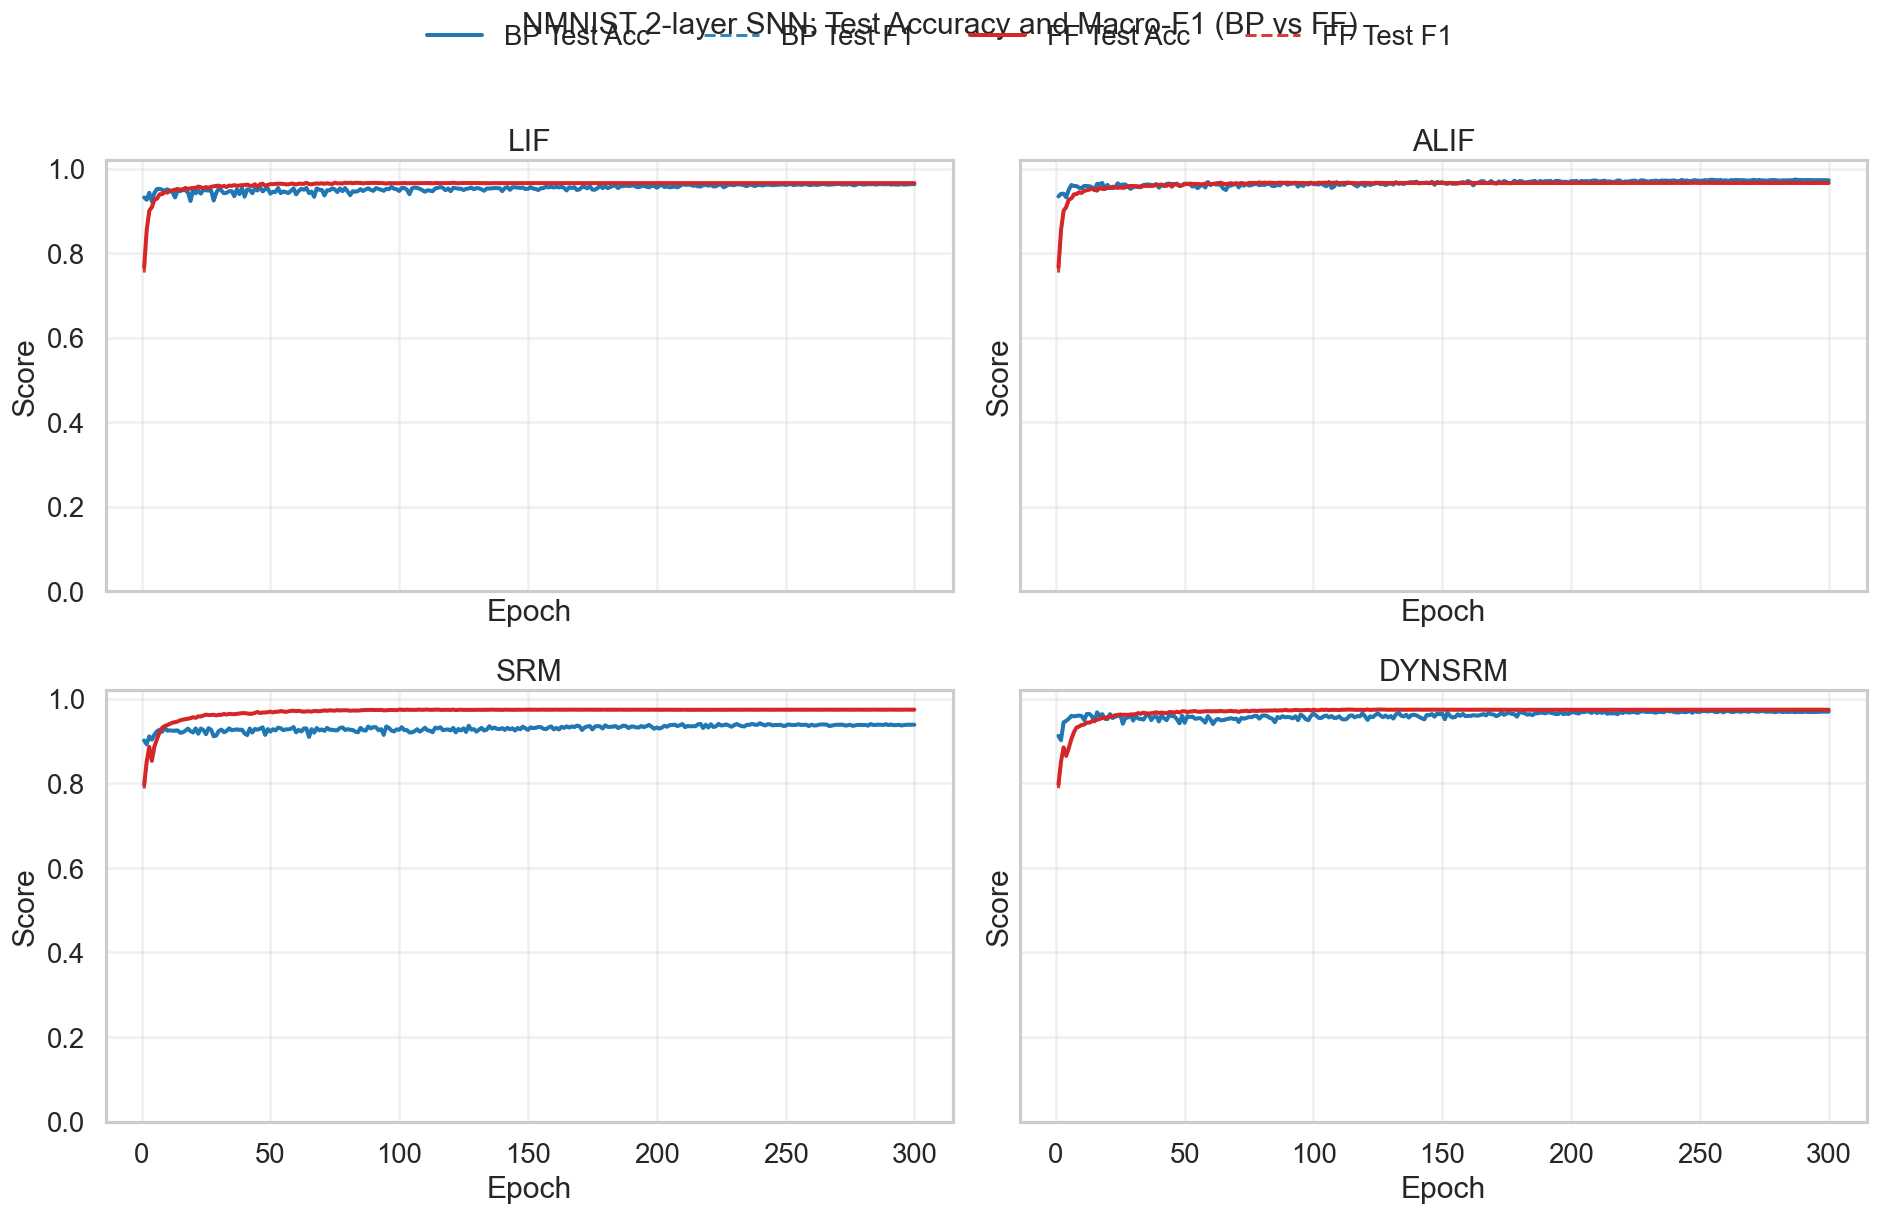

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/curve_accuracy_f1_bp_vs_ff.png


In [3]:
palette = {"BP": "#1f77b4", "FF": "#d62728"}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, model in enumerate(MODELS):
    ax = axes[i]
    for method in ["BP", "FF"]:
        df = runs[(method, model)]
        ax.plot(df["epoch"], df["test_acc"], color=palette[method], linewidth=2.4, label=f"{method} Test Acc")
        ax.plot(df["epoch"], df["test_macro_f1"], color=palette[method], linewidth=1.8, linestyle="--", alpha=0.9, label=f"{method} Test F1")
    ax.set_title(model.upper())
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
fig.suptitle("NMNIST 2-layer SNN: Test Accuracy and Macro-F1 (BP vs FF)", y=1.02, fontsize=18)
fig.tight_layout()

curve_path = OUT_DIR / "curve_accuracy_f1_bp_vs_ff.png"
fig.savefig(curve_path, bbox_inches="tight")
plt.show()
print("Saved:", curve_path)

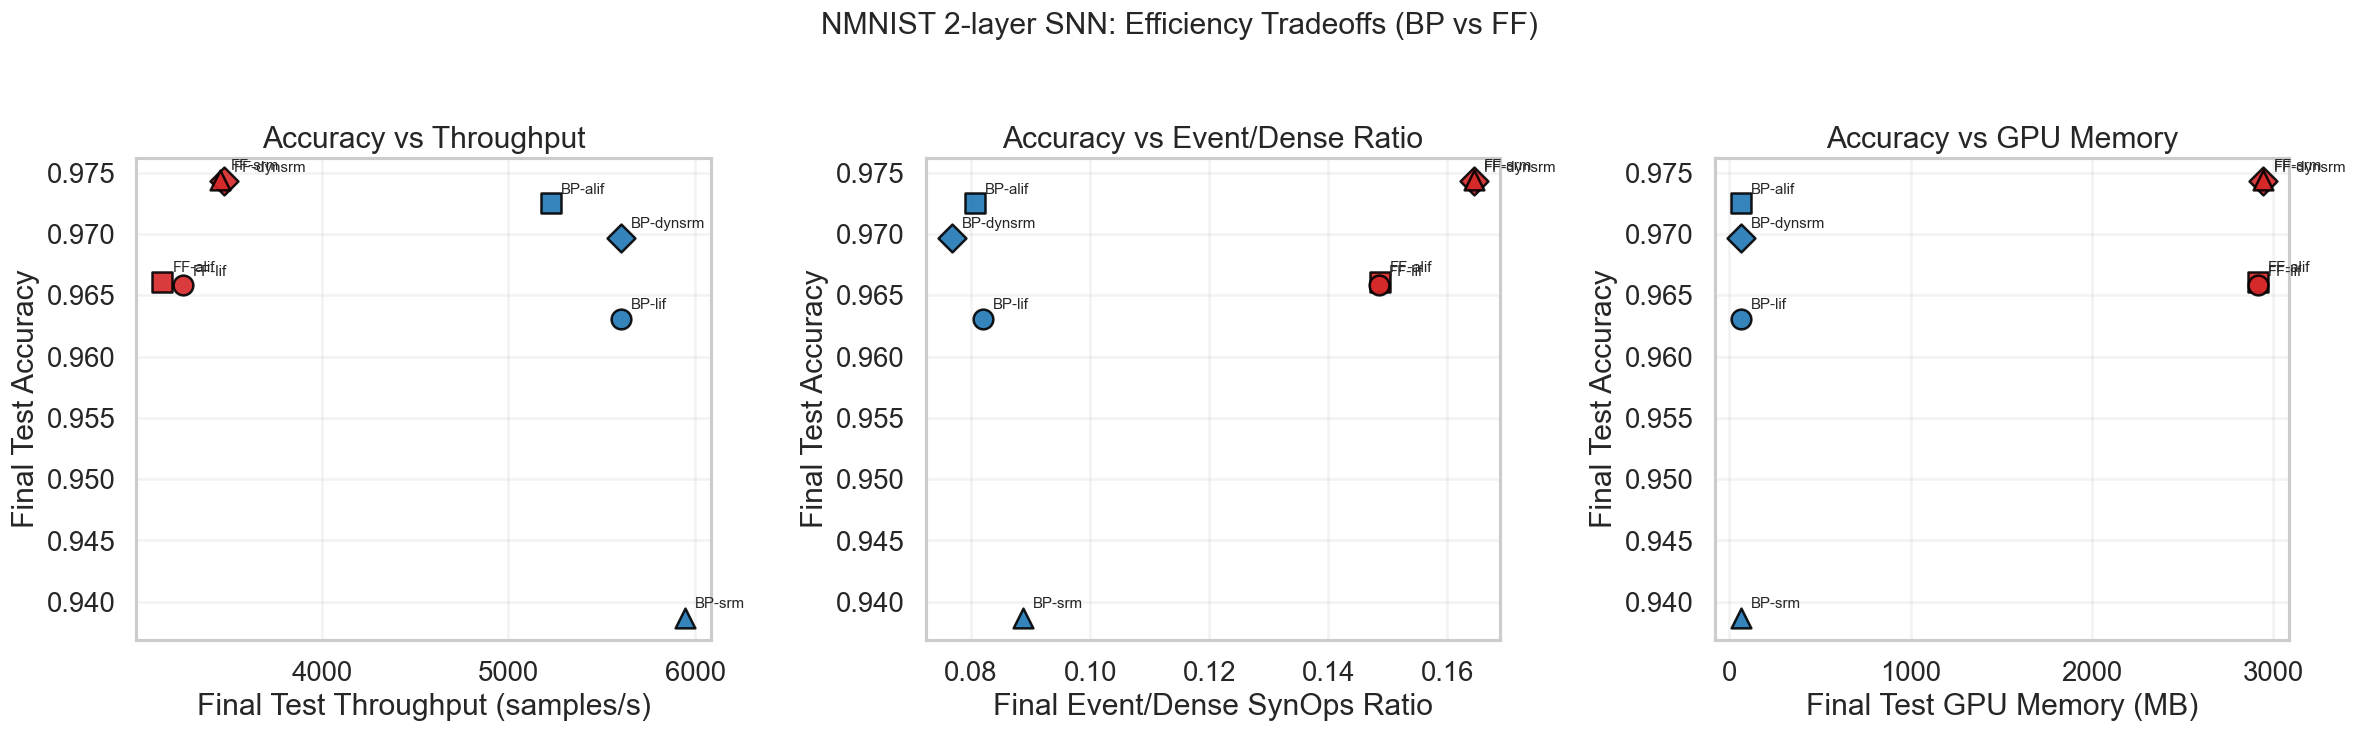

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/tradeoff_speed_energy_accuracy_bp_vs_ff.png


In [4]:
marker_map = {"lif": "o", "alif": "s", "srm": "^", "dynsrm": "D"}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Accuracy vs speed
ax = axes[0]
for _, r in summary_df.iterrows():
    ax.scatter(r["final_test_speed_sps"], r["final_test_acc"], s=140,
               color=palette[r["method"]], marker=marker_map[r["model"]], edgecolor="black", alpha=0.9)
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_test_speed_sps"], r["final_test_acc"]), fontsize=9,
                xytext=(6, 6), textcoords="offset points")
ax.set_title("Accuracy vs Throughput")
ax.set_xlabel("Final Test Throughput (samples/s)")
ax.set_ylabel("Final Test Accuracy")
ax.grid(True, alpha=0.25)

# Accuracy vs event ratio
ax = axes[1]
for _, r in summary_df.iterrows():
    ax.scatter(r["final_event_ratio"], r["final_test_acc"], s=140,
               color=palette[r["method"]], marker=marker_map[r["model"]], edgecolor="black", alpha=0.9)
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_event_ratio"], r["final_test_acc"]), fontsize=9,
                xytext=(6, 6), textcoords="offset points")
ax.set_title("Accuracy vs Event/Dense Ratio")
ax.set_xlabel("Final Event/Dense SynOps Ratio")
ax.set_ylabel("Final Test Accuracy")
ax.grid(True, alpha=0.25)

# Accuracy vs GPU memory
ax = axes[2]
for _, r in summary_df.iterrows():
    ax.scatter(r["final_test_gpu_alloc_mb"], r["final_test_acc"], s=140,
               color=palette[r["method"]], marker=marker_map[r["model"]], edgecolor="black", alpha=0.9)
    ax.annotate(f"{r['method']}-{r['model']}", (r["final_test_gpu_alloc_mb"], r["final_test_acc"]), fontsize=9,
                xytext=(6, 6), textcoords="offset points")
ax.set_title("Accuracy vs GPU Memory")
ax.set_xlabel("Final Test GPU Memory (MB)")
ax.set_ylabel("Final Test Accuracy")
ax.grid(True, alpha=0.25)

fig.suptitle("NMNIST 2-layer SNN: Efficiency Tradeoffs (BP vs FF)", y=1.03, fontsize=18)
fig.tight_layout()

tradeoff_path = OUT_DIR / "tradeoff_speed_energy_accuracy_bp_vs_ff.png"
fig.savefig(tradeoff_path, bbox_inches="tight")
plt.show()
print("Saved:", tradeoff_path)

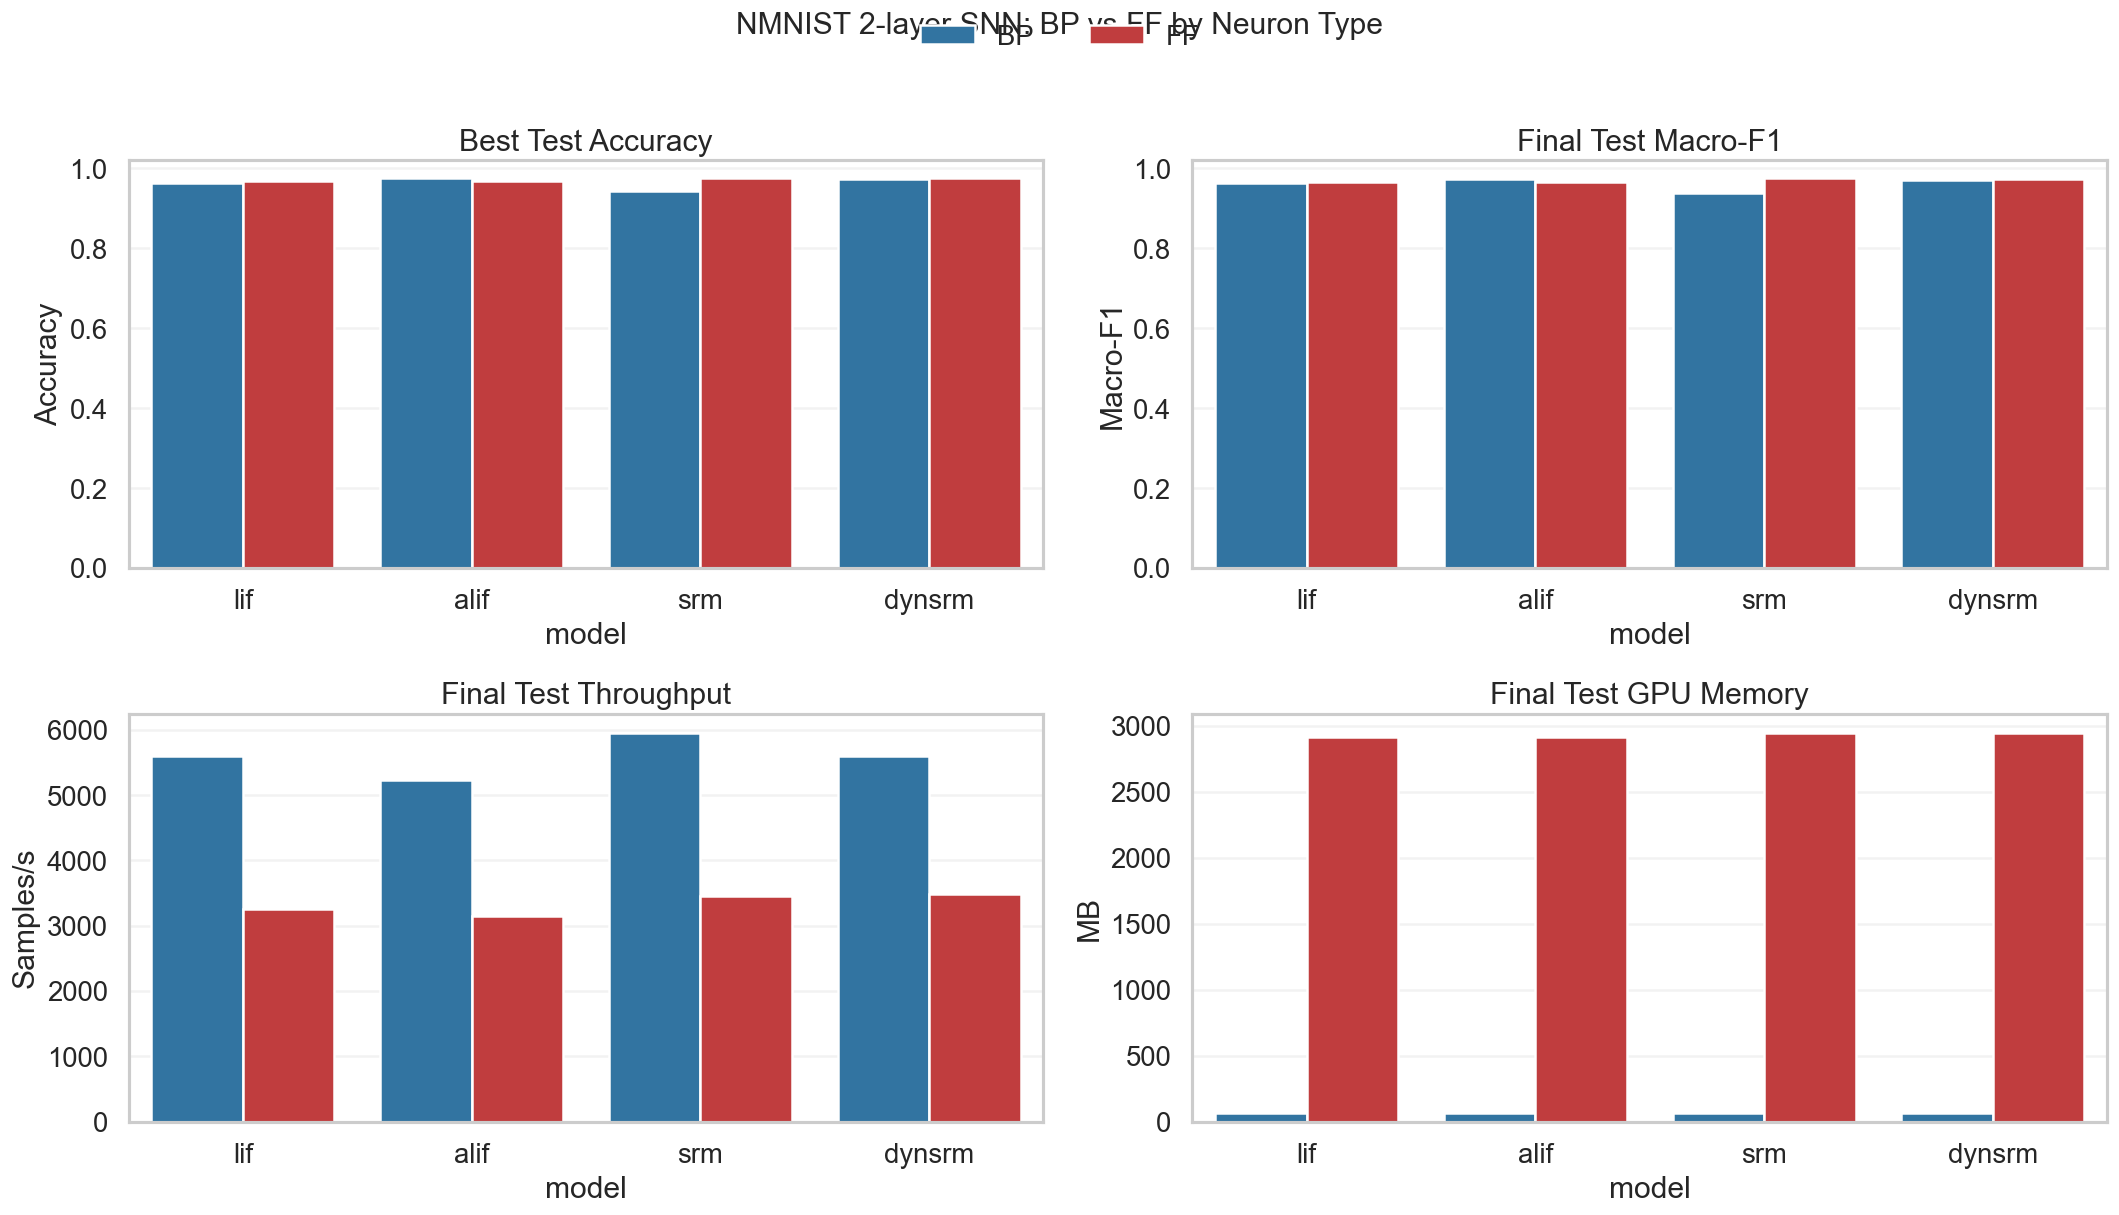

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/bar_accuracy_memory_bp_vs_ff.png


In [4]:
plot_df = summary_df.copy()
plot_df["model"] = pd.Categorical(plot_df["model"], categories=MODELS, ordered=True)
plot_df = plot_df.sort_values(["model", "method"])

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(data=plot_df, x="model", y="best_test_acc", hue="method", palette=palette, ax=axes[0, 0])
axes[0, 0].set_title("Best Test Accuracy")
axes[0, 0].set_ylim(0.0, 1.02)
axes[0, 0].set_ylabel("Accuracy")

sns.barplot(data=plot_df, x="model", y="final_test_macro_f1", hue="method", palette=palette, ax=axes[0, 1])
axes[0, 1].set_title("Final Test Macro-F1")
axes[0, 1].set_ylim(0.0, 1.02)
axes[0, 1].set_ylabel("Macro-F1")

sns.barplot(data=plot_df, x="model", y="final_test_speed_sps", hue="method", palette=palette, ax=axes[1, 0])
axes[1, 0].set_title("Final Test Throughput")
axes[1, 0].set_ylabel("Samples/s")

sns.barplot(data=plot_df, x="model", y="final_test_gpu_alloc_mb", hue="method", palette=palette, ax=axes[1, 1])
axes[1, 1].set_title("Final Test GPU Memory")
axes[1, 1].set_ylabel("MB")

for ax in axes.ravel():
    ax.grid(True, axis="y", alpha=0.25)
    if ax.legend_ is not None:
        ax.legend_.remove()

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
fig.suptitle("NMNIST 2-layer SNN: BP vs FF by Neuron Type", y=1.02, fontsize=18)
fig.tight_layout()

bar_path = OUT_DIR / "bar_accuracy_memory_bp_vs_ff.png"
fig.savefig(bar_path, bbox_inches="tight")
plt.show()
print("Saved:", bar_path)

In [5]:
acc_pivot = summary_df.pivot(index="model", columns="method", values="best_test_acc")
f1_pivot = summary_df.pivot(index="model", columns="method", values="best_test_macro_f1")
speed_pivot = summary_df.pivot(index="model", columns="method", values="final_test_speed_sps")
ratio_pivot = summary_df.pivot(index="model", columns="method", values="final_event_ratio")

delta_df = pd.DataFrame(index=MODELS)
delta_df["delta_best_acc_FF_minus_BP"] = acc_pivot["FF"] - acc_pivot["BP"]
delta_df["delta_best_f1_FF_minus_BP"] = f1_pivot["FF"] - f1_pivot["BP"]
delta_df["delta_speed_FF_minus_BP"] = speed_pivot["FF"] - speed_pivot["BP"]
delta_df["delta_event_ratio_FF_minus_BP"] = ratio_pivot["FF"] - ratio_pivot["BP"]

delta_path = OUT_DIR / "bp_ff_nmnist_delta_table.csv"
delta_df.to_csv(delta_path, index=True)

print("Saved:", summary_path)
print("Saved:", delta_path)
delta_df

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_nmnist_summary_table.csv
Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_nmnist_delta_table.csv


,delta_best_acc_FF_minus_BP,delta_best_f1_FF_minus_BP,delta_speed_FF_minus_BP,delta_event_ratio_FF_minus_BP
lif,0.0029,0.002865,-2347.489317,0.066450
alif,-0.0066,-0.006770,-2083.930069,0.067990
srm,0.0324,0.032656,-2490.165220,0.075739
dynsrm,0.0026,0.002760,-2126.628329,0.087736


/tmp/ipykernel_2505592/568374217.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["LIF", "ALIF", "SRM", "DynamicSRM"], fontsize=12)


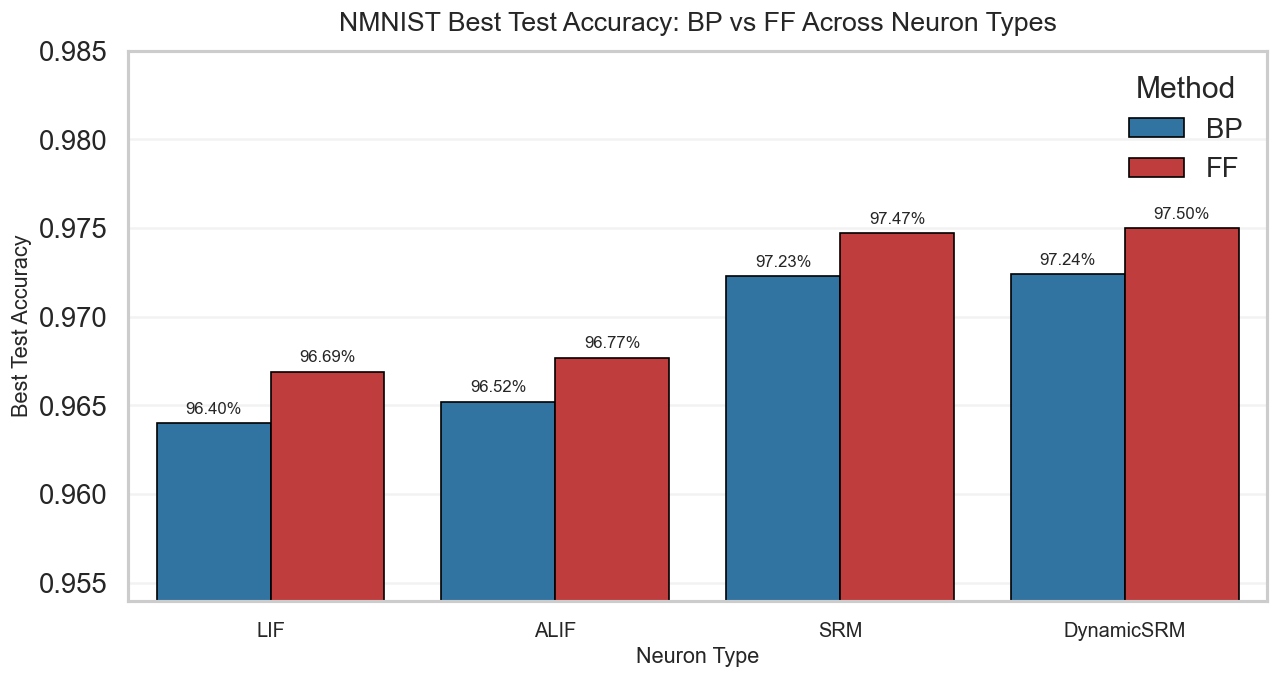

Saved: /home/yhxu/spikingjelly/spikingjelly/spikingjelly/SNNFF/BP/NMNIST/v2/result/2layers/visualizations_bp_ff/bp_ff_nmnist_best_test_accuracy_clear_bar.png
Current NMNIST accuracy table used for plotting:


,model,method,best_test_acc
0,lif,BP,0.9640
1,lif,FF,0.9669
2,alif,BP,0.9652
3,alif,FF,0.9677
4,srm,BP,0.9723
5,srm,FF,0.9747
6,dynsrm,BP,0.9724
7,dynsrm,FF,0.9750


In [7]:
# Clear grouped bar chart: BP vs FF test accuracy by neuron type (NMNIST)
# ------------------------------------------------------------------
# You can edit the numbers below directly.
# Values are fractions in [0, 1], e.g. 0.9412 means 94.12%.
MANUAL_ACC_NMNIST = {
    "lif": {"BP": None, "FF": None},
    "alif": {"BP": 0.9652, "FF": None},
    "srm": {"BP": 0.9723, "FF": None},
    "dynsrm": {"BP": None, "FF": None},
}
# ------------------------------------------------------------------

# Start from computed values, then overwrite with MANUAL_ACC_NMNIST when provided.
acc_plot = summary_df[["model", "method", "best_test_acc"]].copy()
for model, method_vals in MANUAL_ACC_NMNIST.items():
    for method, val in method_vals.items():
        if val is not None:
            mask = (acc_plot["model"] == model) & (acc_plot["method"] == method)
            acc_plot.loc[mask, "best_test_acc"] = float(val)

acc_plot["model"] = pd.Categorical(acc_plot["model"], categories=["lif", "alif", "srm", "dynsrm"], ordered=True)
acc_plot = acc_plot.sort_values(["model", "method"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=acc_plot,
    x="model",
    y="best_test_acc",
    hue="method",
    order=["lif", "alif", "srm", "dynsrm"],
    hue_order=["BP", "FF"],
    palette={"BP": "#1f77b4", "FF": "#d62728"},
    edgecolor="black",
    linewidth=1.0,
    ax=ax,
)

# Add value labels on top of bars
for p in ax.patches:
    h = p.get_height()
    if np.isfinite(h):
        ax.annotate(
            f"{h*100:.2f}%",
            (p.get_x() + p.get_width() / 2.0, h),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points",
        )

ax.set_title("NMNIST Best Test Accuracy: BP vs FF Across Neuron Types", fontsize=16, pad=12)
ax.set_xlabel("Neuron Type", fontsize=13)
ax.set_ylabel("Best Test Accuracy", fontsize=13)

# Start y-axis near the data range to better reveal small differences.
y_min = float(acc_plot["best_test_acc"].min())
y_max = float(acc_plot["best_test_acc"].max())
ax.set_ylim(max(0.0, y_min - 0.01), min(1.02, y_max + 0.01))

ax.set_xticklabels(["LIF", "ALIF", "SRM", "DynamicSRM"], fontsize=12)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(title="Method", frameon=False, loc="upper right")

fig.tight_layout()
acc_bar_path = OUT_DIR / "bp_ff_nmnist_best_test_accuracy_clear_bar.png"
fig.savefig(acc_bar_path, bbox_inches="tight")
plt.show()

print("Saved:", acc_bar_path)
print("Current NMNIST accuracy table used for plotting:")
acc_plot